Imports and basic settings

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

TRAIN_PATH = "data/training_set_VU_DM.csv"

# For first exploration, you can set this to e.g. 500_000.
# For the full dataset, set SAMPLE_NROWS = None.
SAMPLE_NROWS = None

# Create folder for saving EDA outputs
OUTPUT_DIR = "eda_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Load training data

In [3]:
# The dataset uses "NULL" for missing values, so we tell pandas to treat it as NaN.
df = pd.read_csv(
    TRAIN_PATH,
    na_values=["NULL"],
    nrows=SAMPLE_NROWS,
    parse_dates=["date_time"],
    low_memory=False
)

print("Data loaded.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

df.head()

Data loaded.
Rows: 4,958,347
Columns: 54


,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,prop_brand_bool,prop_location_score1,prop_location_score2,prop_log_historical_price,position,price_usd,promotion_flag,srch_destination_id,srch_length_of_stay,srch_booking_window,srch_adults_count,srch_children_count,srch_room_count,srch_saturday_night_bool,srch_query_affinity_score,orig_destination_distance,random_bool,comp1_rate,comp1_inv,comp1_rate_percent_diff,comp2_rate,comp2_inv,comp2_rate_percent_diff,comp3_rate,comp3_inv,comp3_rate_percent_diff,comp4_rate,comp4_inv,comp4_rate_percent_diff,comp5_rate,comp5_inv,comp5_rate_percent_diff,comp6_rate,comp6_inv,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5000,1,2.8300,0.0438,4.9500,27,104.7700,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,0.0000,0.0000,NaN,0.0000,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0000,1,2.2000,0.0149,5.0300,26,170.7400,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,NaN,NaN,NaN,0.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5000,1,2.2000,0.0245,4.9200,21,179.8000,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,0.0000,0.0000,NaN,0.0000,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0000,1,2.8300,0.0125,4.3900,34,602.7700,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,-1.0000,0.0000,5.0000,-1.0000,0.0000,5.0000,NaN,NaN,NaN,0.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0000,0.0000,5.0000,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5000,1,2.6400,0.1241,4.9300,4,143.5800,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,0.0000,0.0000,NaN,0.0000,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,0,NaN,0


Basic dataset overview

In [4]:
overview = {
    "number_of_rows": len(df),
    "number_of_columns": df.shape[1],
    "unique_searches": df["srch_id"].nunique(),
    "unique_properties": df["prop_id"].nunique(),
    "unique_destinations": df["srch_destination_id"].nunique(),
    "date_min": df["date_time"].min(),
    "date_max": df["date_time"].max()
}

overview_df = pd.DataFrame.from_dict(overview, orient="index", columns=["value"])
overview_df

,value
number_of_rows,4958347
number_of_columns,54
unique_searches,199795
unique_properties,129113
unique_destinations,18127
date_min,2012-11-01 00:08:29
date_max,2013-06-30 23:58:24


Hotels per search -> how many hotel options were shown for one search query

In [5]:
hotels_per_search = df.groupby("srch_id")["prop_id"].count()

hotels_per_search_summary = hotels_per_search.describe().to_frame("hotels_per_search")
hotels_per_search_summary

,hotels_per_search
count,"199,795.0000"
mean,24.8172
std,9.1133
min,5.0000
25%,18.0000
50%,29.0000
75%,32.0000
max,38.0000


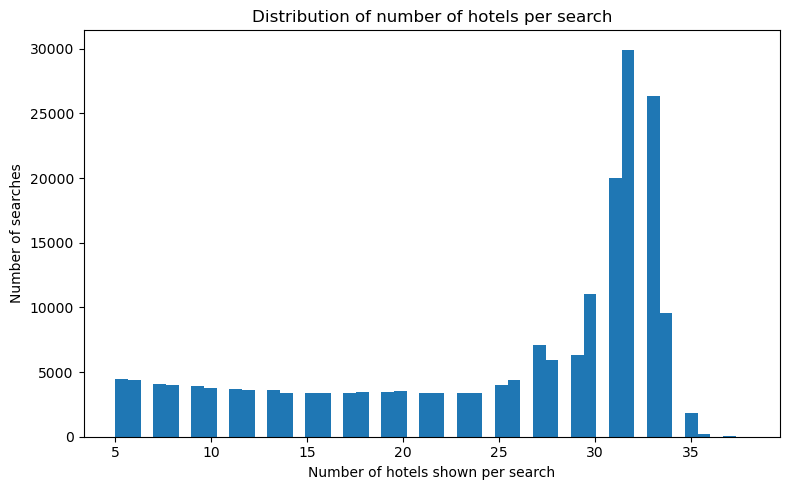

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(hotels_per_search, bins=50)
plt.xlabel("Number of hotels shown per search")
plt.ylabel("Number of searches")
plt.title("Distribution of number of hotels per search")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hotels_per_search_distribution.png", dpi=300)
plt.show()

Group collumns by meaning

In [7]:
search_user_features = [
    "srch_id", "date_time", "site_id", "visitor_location_country_id",
    "visitor_hist_starrating", "visitor_hist_adr_usd",
    "srch_destination_id", "srch_length_of_stay", "srch_booking_window",
    "srch_adults_count", "srch_children_count", "srch_room_count",
    "srch_saturday_night_bool", "srch_query_affinity_score",
    "orig_destination_distance", "random_bool"
]

property_features = [
    "prop_country_id", "prop_id", "prop_starrating", "prop_review_score",
    "prop_brand_bool", "prop_location_score1", "prop_location_score2",
    "prop_log_historical_price", "price_usd", "promotion_flag"
]

competitor_features = [
    col for col in df.columns
    if col.startswith("comp")
]

training_only_features = [
    "position", "click_bool", "gross_bookings_usd", "booking_bool"
]

column_groups = pd.DataFrame({
    "group": (
        ["search/user"] * len(search_user_features)
        + ["property"] * len(property_features)
        + ["competitor"] * len(competitor_features)
        + ["training_only"] * len(training_only_features)
    ),
    "column": search_user_features + property_features + competitor_features + training_only_features
})

column_groups

,group,column
0,search/user,srch_id
1,search/user,date_time
2,search/user,site_id
3,search/user,visitor_location_country_id
4,search/user,visitor_hist_starrating
5,search/user,visitor_hist_adr_usd
6,search/user,srch_destination_id
7,search/user,srch_length_of_stay
8,search/user,srch_booking_window
9,search/user,srch_adults_count


Missing values table

In [8]:
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100,
    "dtype": df.dtypes.astype(str)
}).sort_values("missing_percentage", ascending=False)

missing_table.head(30)

,missing_count,missing_percentage,dtype
comp1_rate_percent_diff,4863908,98.0954,float64
comp6_rate_percent_diff,4862173,98.0604,float64
comp1_rate,4838417,97.5813,float64
comp1_inv,4828788,97.3871,float64
comp4_rate_percent_diff,4827261,97.3563,float64
gross_bookings_usd,4819957,97.2089,float64
comp7_rate_percent_diff,4819832,97.2064,float64
comp6_rate,4718190,95.1565,float64
visitor_hist_starrating,4706481,94.9204,float64
visitor_hist_adr_usd,4705359,94.8977,float64


In [9]:
# save missing values
missing_table.to_csv(f"{OUTPUT_DIR}/missing_values_table.csv")
print(f"Saved missing values table to {OUTPUT_DIR}/missing_values_table.csv")

Saved missing values table to eda_outputs/missing_values_table.csv


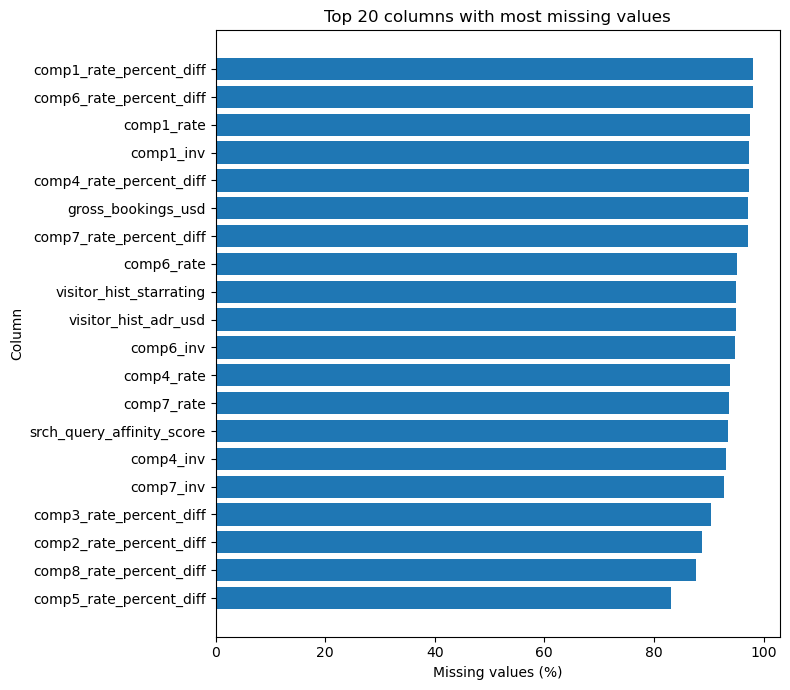

In [10]:
# plot top missing-value columns

top_missing = missing_table.head(20).sort_values("missing_percentage")

plt.figure(figsize=(8, 7))
plt.barh(top_missing.index, top_missing["missing_percentage"])
plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.title("Top 20 columns with most missing values")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/top_missing_values.png", dpi=300)
plt.show()

Check logical ranges of important numerical variables

In [11]:
important_numeric_cols = [
    "visitor_hist_starrating",
    "visitor_hist_adr_usd",
    "prop_starrating",
    "prop_review_score",
    "prop_location_score1",
    "prop_location_score2",
    "prop_log_historical_price",
    "price_usd",
    "srch_length_of_stay",
    "srch_booking_window",
    "srch_adults_count",
    "srch_children_count",
    "srch_room_count",
    "orig_destination_distance",
    "position",
    "click_bool",
    "booking_bool",
    "gross_bookings_usd"
]

important_numeric_cols = [col for col in important_numeric_cols if col in df.columns]

range_table = df[important_numeric_cols].describe().T
range_table

,count,mean,std,min,25%,50%,75%,max
visitor_hist_starrating,"251,866.0000",3.3743,0.6925,1.4100,2.9200,3.4500,3.9300,5.0000
visitor_hist_adr_usd,"252,988.0000",176.0227,107.2545,0.0000,109.8100,152.2400,213.4900,"1,958.7000"
prop_starrating,"4,958,347.0000",3.1805,1.0510,0.0000,3.0000,3.0000,4.0000,5.0000
prop_review_score,"4,950,983.0000",3.7778,1.0503,0.0000,3.5000,4.0000,4.5000,5.0000
prop_location_score1,"4,958,347.0000",2.8726,1.5310,0.0000,1.7900,2.7700,4.0400,6.9800
prop_location_score2,"3,867,999.0000",0.1304,0.1595,0.0000,0.0190,0.0690,0.1805,1.0000
prop_log_historical_price,"4,958,347.0000",4.3179,1.8349,0.0000,4.4500,4.9100,5.3100,6.2100
price_usd,"4,958,347.0000",254.2096,"16,001.2371",0.0000,85.0000,122.0000,184.9600,"19,726,328.0000"
srch_length_of_stay,"4,958,347.0000",2.3854,2.0532,1.0000,1.0000,2.0000,3.0000,57.0000
srch_booking_window,"4,958,347.0000",37.4742,51.9934,0.0000,4.0000,17.0000,48.0000,492.0000


In [12]:
# check suspicious/extreme price values
price_summary = df["price_usd"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame()
price_summary

,price_usd
count,"4,958,347.0000"
mean,254.2096
std,"16,001.2371"
min,0.0000
1%,34.0000
5%,51.0000
25%,85.0000
50%,122.0000
75%,184.9600
95%,356.0000


In [13]:
# inspect very high prices
# very high prices can distort plots and models
# this shows the top 20 most expensive rows in the loaded data
df.sort_values("price_usd", ascending=False)[
    ["srch_id", "prop_id", "price_usd", "srch_length_of_stay", "prop_starrating",
     "prop_review_score", "click_bool", "booking_bool"]
].head(20)

,srch_id,prop_id,price_usd,srch_length_of_stay,prop_starrating,prop_review_score,click_bool,booking_bool
1168566,78107,39677,"19,726,328.0000",4,5,5.0000,0,0
680748,45559,114295,"11,818,011.0000",3,4,0.0000,0,0
3117007,209314,130892,"9,381,308.7100",1,5,5.0000,0,0
1168574,78107,81654,"5,444,467.0000",4,5,4.5000,0,0
2945135,197817,17580,"4,973,355.0000",4,4,4.0000,0,0
1168576,78107,87788,"4,884,239.0000",4,5,4.5000,0,0
1168562,78107,7077,"4,339,792.0000",4,5,4.5000,0,0
1168580,78107,101697,"4,260,887.0000",4,5,4.5000,0,0
4172824,279943,54596,"4,216,286.0000",2,4,4.0000,0,0
1168583,78107,120822,"3,905,813.0000",4,5,4.5000,0,0


Target variables

In [14]:
target_counts = pd.DataFrame({
    "count": [
        df["click_bool"].sum(),
        df["booking_bool"].sum(),
        len(df) - df["click_bool"].sum(),
        len(df) - df["booking_bool"].sum()
    ]
}, index=[
    "clicked_rows",
    "booked_rows",
    "not_clicked_rows",
    "not_booked_rows"
])

target_counts["percentage_of_rows"] = target_counts["count"] / len(df) * 100
target_counts

,count,percentage_of_rows
clicked_rows,221879,4.4749
booked_rows,138390,2.7911
not_clicked_rows,4736468,95.5251
not_booked_rows,4819957,97.2089


In [15]:
# search-level target distribution
search_target_summary = df.groupby("srch_id").agg(
    hotels_in_search=("prop_id", "count"),
    clicks_in_search=("click_bool", "sum"),
    bookings_in_search=("booking_bool", "sum")
)

search_level_counts = pd.DataFrame({
    "searches_total": [len(search_target_summary)],
    "searches_with_at_least_one_click": [(search_target_summary["clicks_in_search"] > 0).sum()],
    "searches_with_at_least_one_booking": [(search_target_summary["bookings_in_search"] > 0).sum()],
})

search_level_counts["percentage_with_click"] = (
    search_level_counts["searches_with_at_least_one_click"] / search_level_counts["searches_total"] * 100
)

search_level_counts["percentage_with_booking"] = (
    search_level_counts["searches_with_at_least_one_booking"] / search_level_counts["searches_total"] * 100
)

search_level_counts

,searches_total,searches_with_at_least_one_click,searches_with_at_least_one_booking,percentage_with_click,percentage_with_booking
0,199795,199795,138390,100.0000,69.2660


Create relevance label for EDA

In [16]:
# Competition-style relevance:
# booking = 5, click without booking = 1, no interaction = 0

df["relevance"] = 0
df.loc[df["click_bool"] == 1, "relevance"] = 1
df.loc[df["booking_bool"] == 1, "relevance"] = 5

df["relevance_group"] = df["relevance"].map({
    0: "ignored",
    1: "clicked_only",
    5: "booked"
})

df[["click_bool", "booking_bool", "relevance", "relevance_group"]].head()

,click_bool,booking_bool,relevance,relevance_group
0,0,0,0,ignored
1,0,0,0,ignored
2,0,0,0,ignored
3,0,0,0,ignored
4,0,0,0,ignored


In [17]:
# relevance distribution
relevance_counts = df["relevance_group"].value_counts(dropna=False).to_frame("count")
relevance_counts["percentage"] = relevance_counts["count"] / len(df) * 100
relevance_counts

,count,percentage
relevance_group,,
ignored,4736468,95.5251
booked,138390,2.7911
clicked_only,83489,1.6838


In [18]:
# compare important features by relevance group
comparison_cols = [
    "price_usd",
    "prop_starrating",
    "prop_review_score",
    "prop_brand_bool",
    "prop_location_score1",
    "prop_location_score2",
    "prop_log_historical_price",
    "promotion_flag",
    "srch_length_of_stay",
    "srch_booking_window",
    "srch_adults_count",
    "srch_children_count",
    "srch_room_count",
    "orig_destination_distance"
]

comparison_cols = [col for col in comparison_cols if col in df.columns]

feature_by_relevance = df.groupby("relevance_group")[comparison_cols].agg(["mean", "median", "std", "count"])
feature_by_relevance

price_usd                               prop_starrating  \
                     mean   median         std    count            mean   
relevance_group                                                           
booked           260.5141 112.8300 16,258.2989   138390          3.3121   
clicked_only     343.9453 127.0000 16,772.5538    83489          3.3598   
ignored          252.4436 122.7500 15,979.7269  4736468          3.1735   

                                       prop_review_score                \
                median    std    count              mean median    std   
relevance_group                                                          
booked          3.0000 0.9500   138390            3.9376 4.0000 0.8033   
clicked_only    3.0000 1.0049    83489            3.8147 4.0000 1.0193   
ignored         3.0000 1.0541  4736468            3.7725 4.0000 1.0568   

                         prop_brand_bool                         \
                   count            mean median    std    count   
relevance_group                                                   
booked            138274          0.6631 1.0000 0.4727   138390   
clicked_only       83349          0.5928 1.0000 0.4913    83489   
ignored          4729360          0.6346 1.0000 0.4815  4736468   

                prop_location_score1                         \
                                mean median    std    count   
relevance_group                                               
booked                        2.8430 2.7100 1.4764   138390   
clicked_only                  2.9627 2.8900 1.5410    83489   
ignored                       2.8719 2.7700 1.5323  4736468   

                prop_location_score2                         \
                                mean median    std    count   
relevance_group                                               
booked                        0.1886 0.1276 0.1874   123916   
clicked_only                  0.1690 0.1019 0.1850    71283   
ignored                       0.1277 0.0668 0.1574  3672800   

                prop_log_historical_price                         \
                                     mean median    std    count   
relevance_group                                                    
booked                             4.3092 4.9300 1.8263   138390   
clicked_only                       4.4081 5.0000 1.8356    83489   
ignored                            4.3166 4.9100 1.8351  4736468   

                promotion_flag                        srch_length_of_stay  \
                          mean median    std    count                mean   
relevance_group                                                             
booked                  0.3031 0.0000 0.4596   138390              2.0896   
clicked_only            0.2698 0.0000 0.4438    83489              2.9425   
ignored                 0.2121 0.0000 0.4088  4736468              2.3843   

                                       srch_booking_window                  \
                median    std    count                mean  median     std   
relevance_group                                                              
booked          2.0000 1.6925   138390             31.4655 13.0000 46.7540   
clicked_only    2.0000 2.5280    83489             48.5239 26.0000 59.8580   
ignored         2.0000 2.0516  4736468             37.4550 17.0000 51.9588   

                         srch_adults_count                         \
                   count              mean median    std    count   
relevance_group                                                     
booked            138390            1.9454 2.0000 0.8790   138390   
clicked_only       83489            2.0663 2.0000 0.8900    83489   
ignored          4736468            1.9718 2.0000 0.8557  4736468   

                srch_children_count                        srch_room_count  \
                               mean median    std    count            mean   
relevance_group                                

In [19]:
# save comparison table
feature_by_relevance.to_csv(f"{OUTPUT_DIR}/feature_by_relevance.csv")
print(f"Saved feature comparison table to {OUTPUT_DIR}/feature_by_relevance.csv")

Saved feature comparison table to eda_outputs/feature_by_relevance.csv


Analyse price

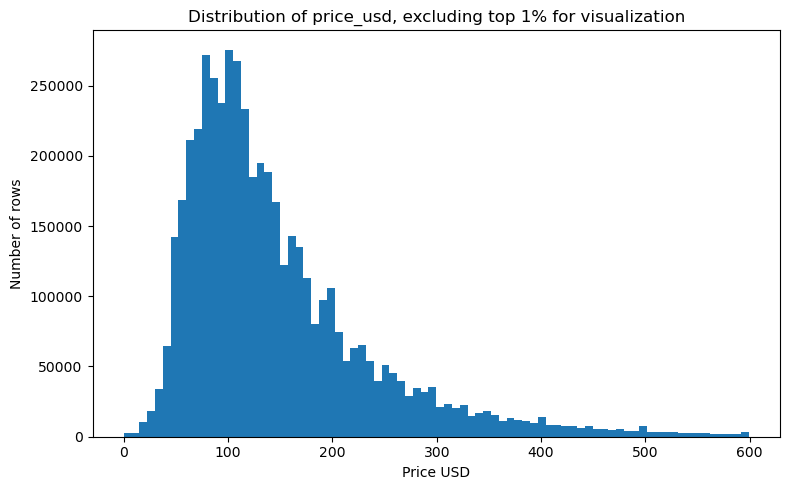

In [20]:
# distribution of price_usd

# Raw price distribution is often very skewed.
# To make the plot readable, we remove the top 1% only for visualization.
price_upper = df["price_usd"].quantile(0.99)
plot_df = df[df["price_usd"] <= price_upper]

plt.figure(figsize=(8, 5))
plt.hist(plot_df["price_usd"].dropna(), bins=80)
plt.xlabel("Price USD")
plt.ylabel("Number of rows")
plt.title("Distribution of price_usd, excluding top 1% for visualization")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/price_distribution_trimmed.png", dpi=300)
plt.show()

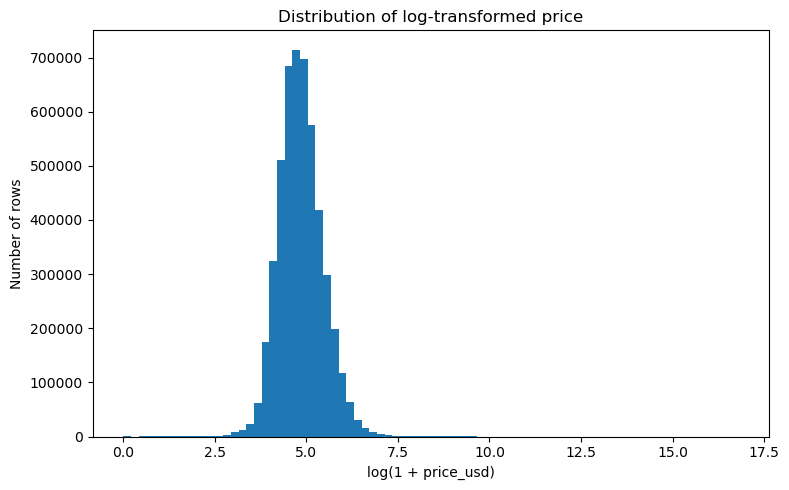

In [21]:
# log price distribution

# log1p(x) = log(1 + x), safer when x can be 0.
df["log_price_usd"] = np.log1p(df["price_usd"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_price_usd"].dropna(), bins=80)
plt.xlabel("log(1 + price_usd)")
plt.ylabel("Number of rows")
plt.title("Distribution of log-transformed price")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/log_price_distribution.png", dpi=300)
plt.show()

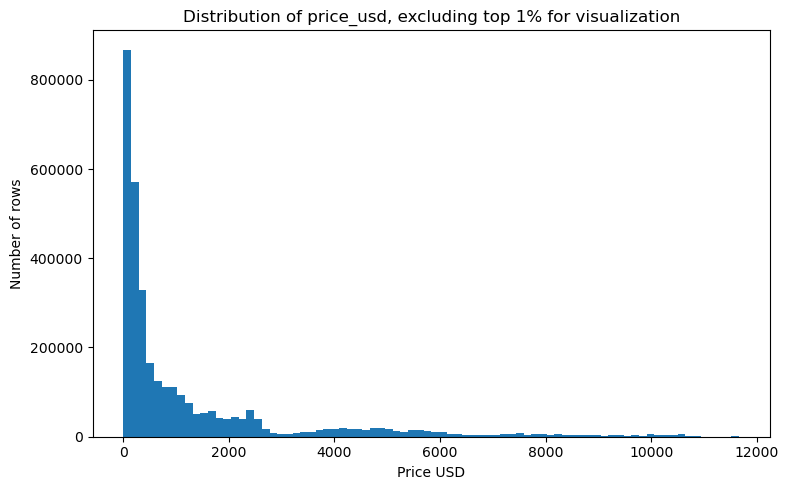

In [22]:
# distribution of price_usd

# Raw price distribution is often very skewed.
# To make the plot readable, we remove the top 1% only for visualization.
price_upper = df["orig_destination_distance"]
plot_df = df[df["orig_destination_distance"] <= price_upper]

plt.figure(figsize=(8, 5))
plt.hist(plot_df["orig_destination_distance"].dropna(), bins=80)
plt.xlabel("Price USD")
plt.ylabel("Number of rows")
plt.title("Distribution of price_usd, excluding top 1% for visualization")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/price_distribution_trimmed.png", dpi=300)
plt.show()

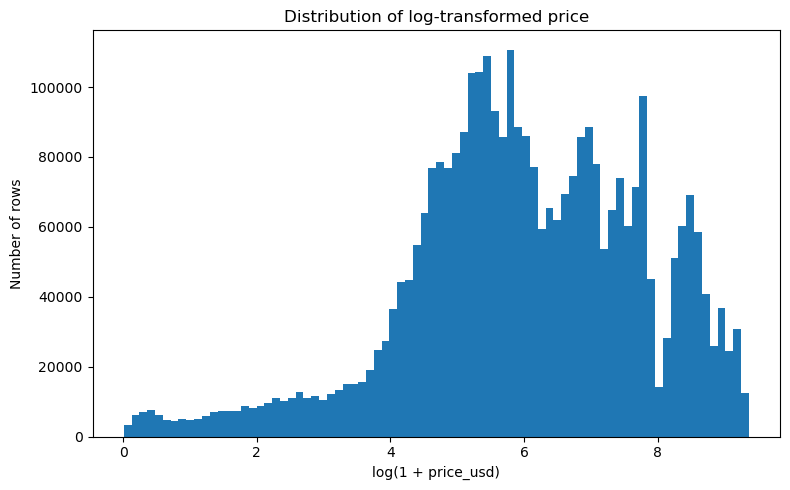

In [ ]:
# log distance distribution

# log1p(x) = log(1 + x), safer when x can be 0.
df["log_orig_destination_distance"] = np.log1p(df["orig_destination_distance"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_orig_destination_distanced"].dropna(), bins=80)
plt.xlabel("log(1 + price_usd)")
plt.ylabel("Number of rows")
plt.title("Distribution of log-transformed price")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/log_price_distribution.png", dpi=300)
plt.show()

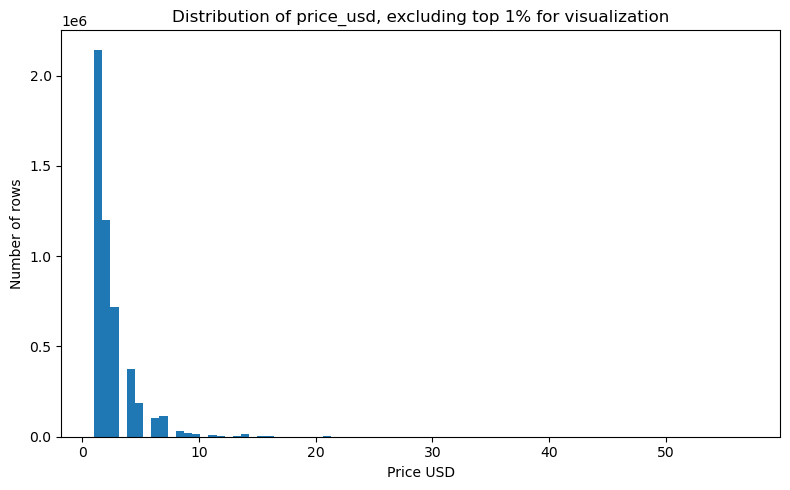

In [47]:
# distribution of price_usd

# Raw price distribution is often very skewed.
# To make the plot readable, we remove the top 1% only for visualization.
price_upper = df["srch_length_of_stay"]
plot_df = df[df["srch_length_of_stay"] <= price_upper]

plt.figure(figsize=(8, 5))
plt.hist(plot_df["srch_length_of_stay"].dropna(), bins=80)
plt.xlabel("Price USD")
plt.ylabel("Number of rows")
plt.title("Distribution of price_usd, excluding top 1% for visualization")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/price_distribution_trimmed.png", dpi=300)
plt.show()

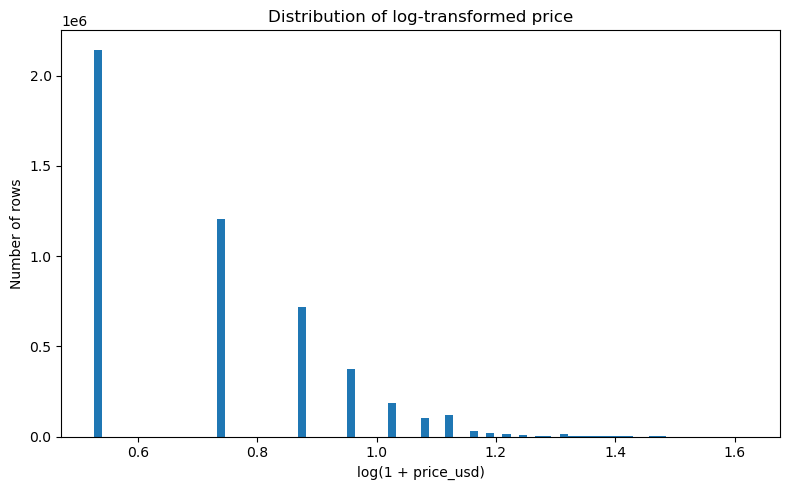

In [49]:
# log distance distribution

# log1p(x) = log(1 + x), safer when x can be 0.
df["log_srch_length_of_stay"] = np.log1p(df["srch_length_of_stay"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_srch_length_of_stay"].dropna(), bins=80)
plt.xlabel("log(1 + price_usd)")
plt.ylabel("Number of rows")
plt.title("Distribution of log-transformed price")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/log_price_distribution.png", dpi=300)
plt.show()

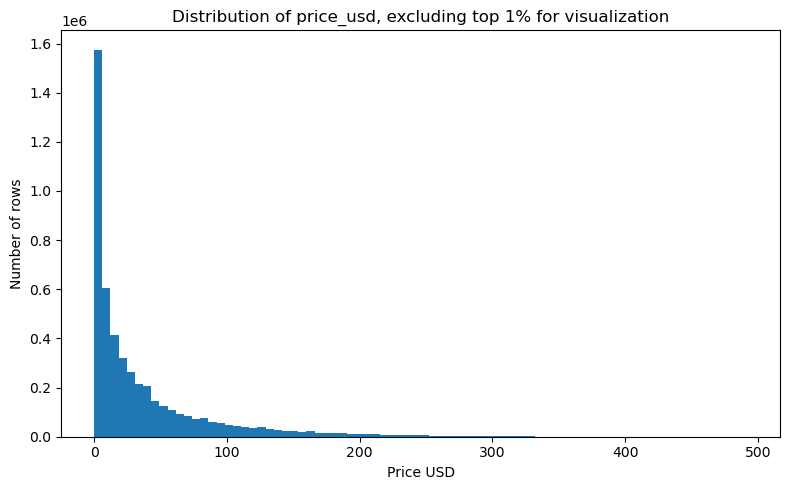

In [50]:
# distribution of price_usd

# Raw price distribution is often very skewed.
# To make the plot readable, we remove the top 1% only for visualization.
price_upper = df["srch_booking_window"]
plot_df = df[df["srch_booking_window"] <= price_upper]

plt.figure(figsize=(8, 5))
plt.hist(plot_df["srch_booking_window"].dropna(), bins=80)
plt.xlabel("Price USD")
plt.ylabel("Number of rows")
plt.title("Distribution of price_usd, excluding top 1% for visualization")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/price_distribution_trimmed.png", dpi=300)
plt.show()

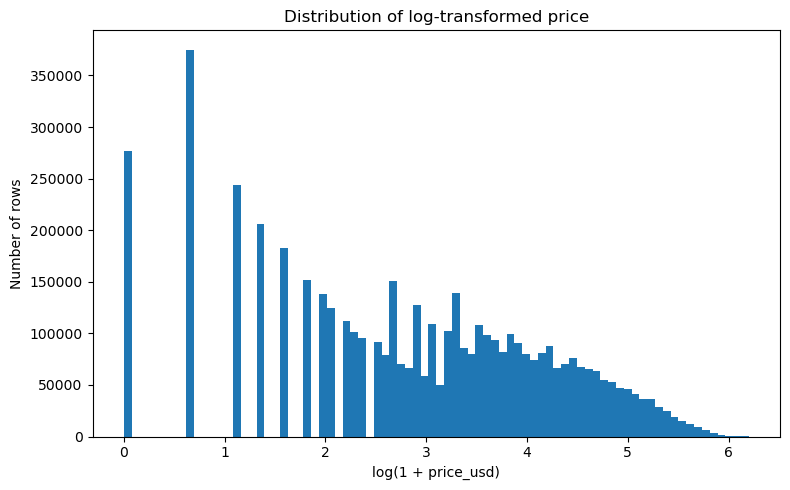

In [ ]:
# log distance distribution

# log1p(x) = log(1 + x), safer when x can be 0.
df["log_srch_booking_window"] = np.log1p(df["srch_booking_window"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_srch_booking_window"].dropna(), bins=80)
plt.xlabel("log(1 + srch_booking_window)")
plt.ylabel("Number of rows")
plt.title("Distribution of log-transformed price")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/log_price_distribution.png", dpi=300)
plt.show()

/var/folders/v7/4rvhk5951gqck0hx9gq2y3040000gn/T/ipykernel_4538/2457197315.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=groups, showfliers=False)


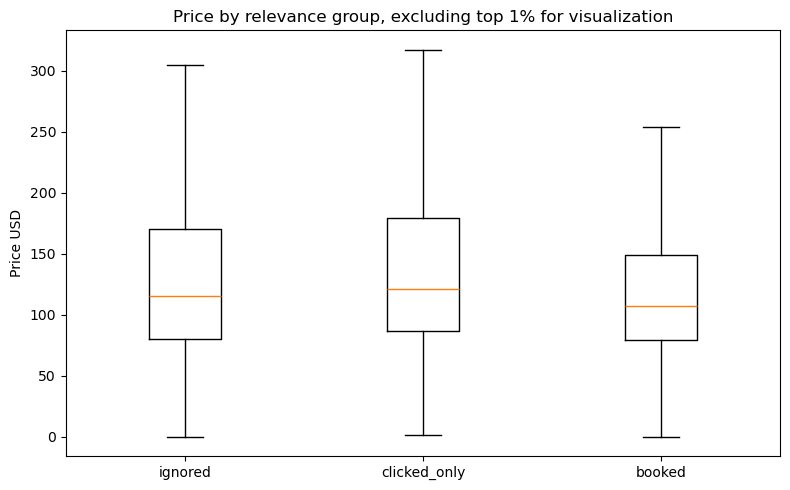

In [23]:
# price by relevance group

plot_df = df[df["price_usd"] <= price_upper].copy()

groups = ["ignored", "clicked_only", "booked"]
data_to_plot = [
    plot_df.loc[plot_df["relevance_group"] == group, "price_usd"].dropna()
    for group in groups
]

plt.figure(figsize=(8, 5))
plt.boxplot(data_to_plot, labels=groups, showfliers=False)
plt.ylabel("Price USD")
plt.title("Price by relevance group, excluding top 1% for visualization")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/price_by_relevance_group.png", dpi=300)
plt.show()

Analyse position

In [24]:
# booking and click rate by position

# IMPORTANT:
# position is training-only. It is useful for EDA, but we shouldn't use it
# as a final model feature

position_stats = df.groupby("position").agg(
    rows=("prop_id", "count"),
    click_rate=("click_bool", "mean"),
    booking_rate=("booking_bool", "mean")
).reset_index()

position_stats.head()

,position,rows,click_rate,booking_rate
0,1,199415,0.1925,0.1410
1,2,199350,0.1342,0.0943
2,3,199355,0.1053,0.0708
3,4,193406,0.0882,0.0579
4,5,9312,0.0226,0.0116


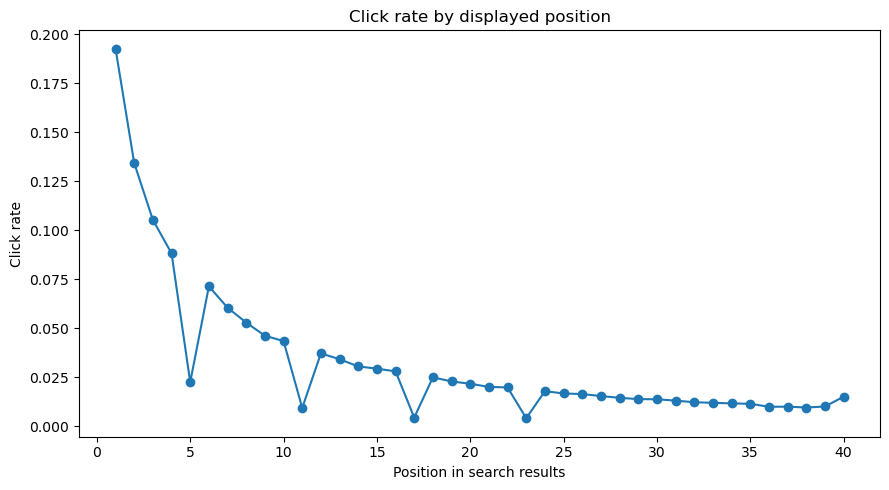

In [25]:
# plot click rate by position
plt.figure(figsize=(9, 5))
plt.plot(position_stats["position"], position_stats["click_rate"], marker="o")
plt.xlabel("Position in search results")
plt.ylabel("Click rate")
plt.title("Click rate by displayed position")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/click_rate_by_position.png", dpi=300)
plt.show()

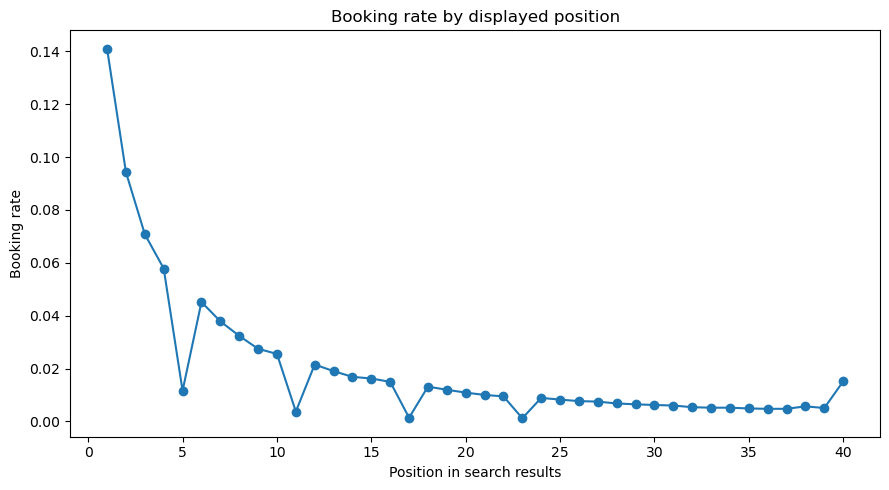

In [26]:
# plot booking rate by position

plt.figure(figsize=(9, 5))
plt.plot(position_stats["position"], position_stats["booking_rate"], marker="o")
plt.xlabel("Position in search results")
plt.ylabel("Booking rate")
plt.title("Booking rate by displayed position")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/booking_rate_by_position.png", dpi=300)
plt.show()

Star rating

In [27]:
# click/booking rate by hotel star rating

star_stats = df.groupby("prop_starrating").agg(
    rows=("prop_id", "count"),
    click_rate=("click_bool", "mean"),
    booking_rate=("booking_bool", "mean"),
    avg_price=("price_usd", "mean"),
    avg_review=("prop_review_score", "mean")
).reset_index()

star_stats

,prop_starrating,rows,click_rate,booking_rate,avg_price,avg_review
0,0,169572,0.0290,0.0165,167.9787,3.0539
1,1,17350,0.0279,0.0133,106.5047,2.6693
2,2,895894,0.0339,0.0218,117.8718,3.2275
3,3,1947598,0.0439,0.0281,182.4065,3.8083
4,4,1521448,0.0538,0.0332,307.8423,4.0218
5,5,406485,0.0461,0.0259,740.2633,4.2781


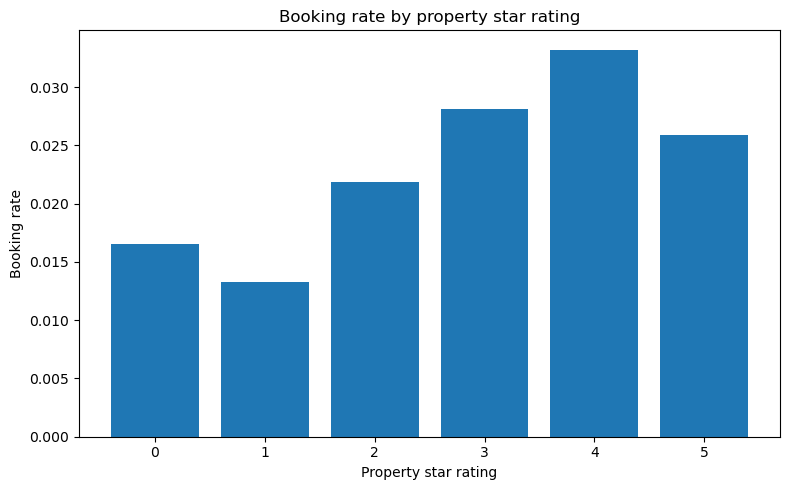

In [28]:
# plot booking rate by hotel star rating

plt.figure(figsize=(8, 5))
plt.bar(star_stats["prop_starrating"], star_stats["booking_rate"])
plt.xlabel("Property star rating")
plt.ylabel("Booking rate")
plt.title("Booking rate by property star rating")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/booking_rate_by_star_rating.png", dpi=300)
plt.show()

Review score

In [29]:
# click/booking rate by review score
review_stats = df.groupby("prop_review_score").agg(
    rows=("prop_id", "count"),
    click_rate=("click_bool", "mean"),
    booking_rate=("booking_bool", "mean"),
    avg_price=("price_usd", "mean")
).reset_index()

review_stats

,prop_review_score,rows,click_rate,booking_rate,avg_price
0,0.0000,233294,0.0296,0.0134,363.9346
1,1.0000,13303,0.0207,0.0071,218.7804
2,1.5000,14465,0.0195,0.0090,118.9700
3,2.0000,62301,0.0242,0.0114,154.0773
4,2.5000,143886,0.0298,0.0160,129.0234
5,3.0000,375905,0.0351,0.0211,126.5983
6,3.5000,768054,0.0452,0.0285,181.0012
7,4.0000,1556948,0.0505,0.0323,235.5203
8,4.5000,1546880,0.0475,0.0303,302.8540
9,5.0000,235947,0.0356,0.0204,505.0807


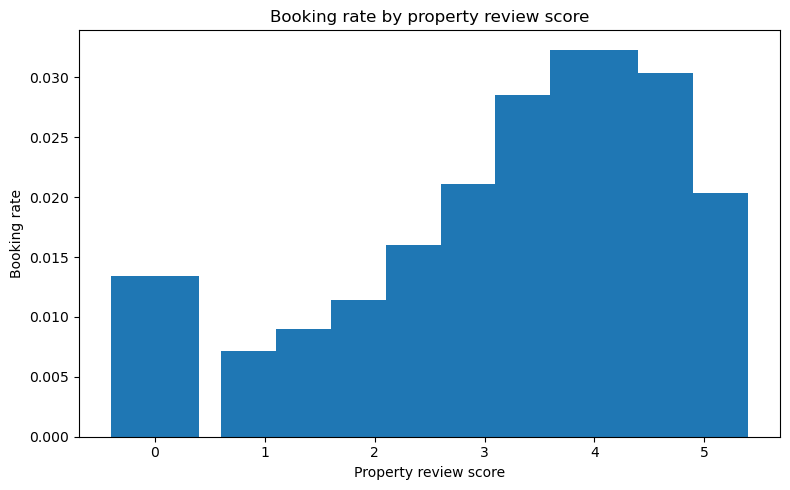

In [30]:
# plot booking rate by review score
plt.figure(figsize=(8, 5))
plt.bar(review_stats["prop_review_score"], review_stats["booking_rate"])
plt.xlabel("Property review score")
plt.ylabel("Booking rate")
plt.title("Booking rate by property review score")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/booking_rate_by_review_score.png", dpi=300)
plt.show()

Promotion

In [31]:
# promotion flag analysis
promotion_stats = df.groupby("promotion_flag").agg(
    rows=("prop_id", "count"),
    click_rate=("click_bool", "mean"),
    booking_rate=("booking_bool", "mean"),
    avg_price=("price_usd", "mean"),
    avg_star_rating=("prop_starrating", "mean"),
    avg_review_score=("prop_review_score", "mean")
).reset_index()

promotion_stats

,promotion_flag,rows,click_rate,booking_rate,avg_price,avg_star_rating,avg_review_score
0,0,3889229,0.0405,0.0248,244.0024,3.0848,3.7458
1,1,1069118,0.0603,0.0392,291.3412,3.5288,3.8939


Brand vs independent hotel analysis

In [32]:
brand_stats = df.groupby("prop_brand_bool").agg(
    rows=("prop_id", "count"),
    click_rate=("click_bool", "mean"),
    booking_rate=("booking_bool", "mean"),
    avg_price=("price_usd", "mean"),
    avg_star_rating=("prop_starrating", "mean"),
    avg_review_score=("prop_review_score", "mean")
).reset_index()

brand_stats

,prop_brand_bool,rows,click_rate,booking_rate,avg_price,avg_star_rating,avg_review_score
0,0,1811287,0.0445,0.0257,275.1594,3.1510,3.4950
1,1,3147060,0.0449,0.0292,242.1520,3.1975,3.9401


Analyse search level competition

In [33]:
# search-level relative features for EDA

# These are not "final preprocessing" yet, but they are useful for EDA.
# They help answer questions like:
# Is the booked hotel cheaper than the average hotel in the same search?
# Is it better rated than other hotels in the same search?

df["search_avg_price"] = df.groupby("srch_id")["price_usd"].transform("mean")
df["search_min_price"] = df.groupby("srch_id")["price_usd"].transform("min")
df["search_max_price"] = df.groupby("srch_id")["price_usd"].transform("max")

df["price_diff_from_search_avg"] = df["price_usd"] - df["search_avg_price"]
df["price_ratio_to_search_avg"] = df["price_usd"] / df["search_avg_price"]
df["price_diff_from_search_min"] = df["price_usd"] - df["search_min_price"]

df["search_avg_star"] = df.groupby("srch_id")["prop_starrating"].transform("mean")
df["star_diff_from_search_avg"] = df["prop_starrating"] - df["search_avg_star"]

df["search_avg_review"] = df.groupby("srch_id")["prop_review_score"].transform("mean")
df["review_diff_from_search_avg"] = df["prop_review_score"] - df["search_avg_review"]

relative_cols = [
    "price_diff_from_search_avg",
    "price_ratio_to_search_avg",
    "price_diff_from_search_min",
    "star_diff_from_search_avg",
    "review_diff_from_search_avg"
]

df[["srch_id", "prop_id", "price_usd", "search_avg_price"] + relative_cols].head()

,srch_id,prop_id,price_usd,search_avg_price,price_diff_from_search_avg,price_ratio_to_search_avg,price_diff_from_search_min,star_diff_from_search_avg,review_diff_from_search_avg
0,1,893,104.7700,163.7189,-58.9489,0.6399,19.4000,-0.0714,0.0179
1,1,10404,170.7400,163.7189,7.0211,1.0429,85.3700,0.9286,0.5179
2,1,21315,179.8000,163.7189,16.0811,1.0982,94.4300,-0.0714,1.0179
3,1,27348,602.7700,163.7189,439.0511,3.6817,517.4000,-1.0714,0.5179
4,1,29604,143.5800,163.7189,-20.1389,0.8770,58.2100,0.9286,0.0179


In [34]:
# compare relative features by relevance group

relative_feature_by_relevance = df.groupby("relevance_group")[relative_cols].agg(
    ["mean", "median", "std", "count"]
)

relative_feature_by_relevance

price_diff_from_search_avg                                \
                                      mean   median         std    count   
relevance_group                                                            
booked                             -9.2393 -16.2009  3,230.4464   138390   
clicked_only                       25.0011 -15.0832  6,269.2847    83489   
ignored                            -0.1707  -7.9500 10,547.5060  4736468   

                price_ratio_to_search_avg                         \
                                     mean median    std    count   
relevance_group                                                    
booked                             0.9100 0.8667 0.3336   138390   
clicked_only                       0.9480 0.8825 0.4438    83489   
ignored                            1.0035 0.9355 0.4583  4736468   

                price_diff_from_search_min                               \
                                      mean  median         std    count   
relevance_group                                                           
booked                            130.4456 44.0000 10,399.0361   138390   
clicked_only                      209.0920 50.3100 12,960.0837    83489   
ignored                           136.2838 56.0000 12,633.2947  4736468   

                star_diff_from_search_avg                         \
                                     mean median    std    count   
relevance_group                                                    
booked                             0.1942 0.2000 0.7413   138390   
clicked_only                       0.1516 0.1500 0.7783    83489   
ignored                           -0.0083 0.0294 0.8069  4736468   

                review_diff_from_search_avg                         
                                       mean median    std    count  
relevance_group                                                     
booked                               0.1713 0.2121 0.7680   138274  
clicked_only                         0.1182 0.2031 0.9185    83349  
ignored                             -0.0071 0.1452 0.9403  4729360

/var/folders/v7/4rvhk5951gqck0hx9gq2y3040000gn/T/ipykernel_4538/412894323.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=groups, showfliers=False)


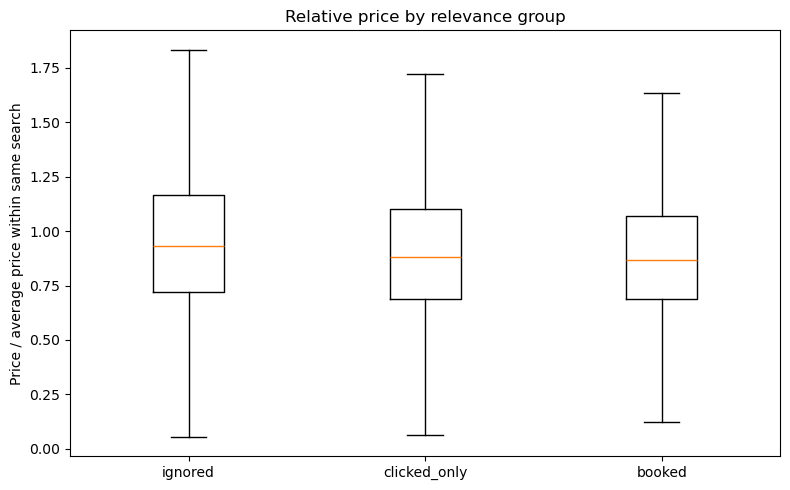

In [35]:
# plot price ratio by relevance group

plot_df = df[
    df["price_ratio_to_search_avg"].notna()
    & np.isfinite(df["price_ratio_to_search_avg"])
    & (df["price_ratio_to_search_avg"] <= df["price_ratio_to_search_avg"].quantile(0.99))
].copy()

data_to_plot = [
    plot_df.loc[plot_df["relevance_group"] == group, "price_ratio_to_search_avg"].dropna()
    for group in groups
]

plt.figure(figsize=(8, 5))
plt.boxplot(data_to_plot, labels=groups, showfliers=False)
plt.ylabel("Price / average price within same search")
plt.title("Relative price by relevance group")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/relative_price_by_relevance_group.png", dpi=300)
plt.show()

Check categorical ID's

In [36]:
# high-cardinality categorical variables

categorical_id_cols = [
    "site_id",
    "visitor_location_country_id",
    "prop_country_id",
    "prop_id",
    "srch_destination_id"
]

categorical_summary = []

for col in categorical_id_cols:
    categorical_summary.append({
        "column": col,
        "unique_values": df[col].nunique(dropna=True),
        "most_common_value": df[col].value_counts(dropna=True).index[0],
        "most_common_count": df[col].value_counts(dropna=True).iloc[0],
        "most_common_percentage": df[col].value_counts(dropna=True).iloc[0] / len(df) * 100
    })

categorical_summary = pd.DataFrame(categorical_summary)
categorical_summary

,column,unique_values,most_common_value,most_common_count,most_common_percentage
0,site_id,34,5,3086006,62.2386
1,visitor_location_country_id,210,219,2892489,58.3358
2,prop_country_id,172,219,3030125,61.1116
3,prop_id,129113,104517,2357,0.0475
4,srch_destination_id,18127,8192,69832,1.4084


In [37]:
# top destinations by number of rows and booking rate

destination_stats = df.groupby("srch_destination_id").agg(
    rows=("prop_id", "count"),
    searches=("srch_id", "nunique"),
    click_rate=("click_bool", "mean"),
    booking_rate=("booking_bool", "mean"),
    avg_price=("price_usd", "mean")
).reset_index()

destination_stats = destination_stats.sort_values("rows", ascending=False)
destination_stats.head(20)

,srch_destination_id,rows,searches,click_rate,booking_rate,avg_price
5266,8192,69832,2464,0.0401,0.0224,150.7438
2961,4562,57090,2038,0.0401,0.0221,406.6205
6016,9402,40629,1378,0.0379,0.0244,210.4773
5361,8347,33274,1192,0.0417,0.0215,135.9782
7006,10979,33264,1239,0.0413,0.0231,241.6828
8460,13292,32094,1166,0.0425,0.0215,242.3462
8842,13870,29614,968,0.0356,0.0226,155.5869
11969,18774,27146,915,0.0379,0.0252,182.9526
15249,23904,26422,919,0.0385,0.0235,"2,653.6933"
8410,13216,23900,825,0.0395,0.0240,180.0462


In [38]:
# top properties by number of appearances and booking rate

property_stats = df.groupby("prop_id").agg(
    rows=("srch_id", "count"),
    searches=("srch_id", "nunique"),
    click_rate=("click_bool", "mean"),
    booking_rate=("booking_bool", "mean"),
    avg_price=("price_usd", "mean"),
    avg_star_rating=("prop_starrating", "mean"),
    avg_review_score=("prop_review_score", "mean")
).reset_index()

property_stats = property_stats.sort_values("rows", ascending=False)
property_stats.head(20)

,prop_id,rows,searches,click_rate,booking_rate,avg_price,avg_star_rating,avg_review_score
95837,104517,2357,2357,0.0738,0.0395,108.3736,4.0000,4.0000
114012,124342,2355,2355,0.0488,0.0310,117.7745,4.0000,4.0000
62782,68420,2285,2285,0.0468,0.0271,65.5934,3.0000,3.5000
36991,40279,2275,2275,0.0505,0.0251,237.6494,5.0000,4.5000
122996,134154,2257,2257,0.0514,0.0385,58.0337,3.0000,3.5000
126508,137997,2247,2247,0.0774,0.0485,134.0527,4.0000,4.0000
54855,59781,2245,2245,0.0365,0.0196,206.7057,5.0000,4.5000
55824,60846,2237,2237,0.0501,0.0295,154.5858,4.0000,4.5000
70718,77089,2230,2230,0.0857,0.0547,75.5058,3.0000,3.5000
45573,49656,2230,2230,0.0296,0.0143,69.9684,3.0000,3.5000


Analyse competitor variables

In [39]:
# competitor feature missingness

competitor_missing = missing_table.loc[competitor_features].sort_values("missing_percentage", ascending=False)
competitor_missing.head(30)

,missing_count,missing_percentage,dtype
comp1_rate_percent_diff,4863908,98.0954,float64
comp6_rate_percent_diff,4862173,98.0604,float64
comp1_rate,4838417,97.5813,float64
comp1_inv,4828788,97.3871,float64
comp4_rate_percent_diff,4827261,97.3563,float64
comp7_rate_percent_diff,4819832,97.2064,float64
comp6_rate,4718190,95.1565,float64
comp6_inv,4697371,94.7366,float64
comp4_rate,4650969,93.8008,float64
comp7_rate,4642999,93.6401,float64


In [40]:
# competitor rate summary

# compX_rate interpretation:
# +1 = Expedia cheaper than competitor
#  0 = same price
# -1 = Expedia more expensive
# NaN = no competitor data

rate_cols = [col for col in competitor_features if col.endswith("_rate")]

rate_summary_rows = []

for col in rate_cols:
    counts = df[col].value_counts(dropna=False)
    rate_summary_rows.append({
        "column": col,
        "missing_percentage": df[col].isna().mean() * 100,
        "expedia_cheaper_percentage": (df[col] == 1).mean() * 100,
        "same_price_percentage": (df[col] == 0).mean() * 100,
        "expedia_more_expensive_percentage": (df[col] == -1).mean() * 100
    })

rate_summary = pd.DataFrame(rate_summary_rows)
rate_summary

,column,missing_percentage,expedia_cheaper_percentage,same_price_percentage,expedia_more_expensive_percentage
0,comp1_rate,97.5813,1.3564,0.8664,0.1959
1,comp2_rate,59.1664,5.0476,32.5429,3.2431
2,comp3_rate,69.0565,3.5116,24.4553,2.9766
3,comp4_rate,93.8008,0.9877,4.1213,1.0902
4,comp5_rate,55.1792,6.6205,32.5962,5.6041
5,comp6_rate,95.1565,1.1097,3.2457,0.4881
6,comp7_rate,93.6401,1.5950,4.0982,0.6667
7,comp8_rate,61.3449,3.1491,30.0029,5.5031


In [41]:
# competitor availability summary

# compX_inv interpretation:
# +1 = competitor has no availability
#  0 = both Expedia and competitor have availability
# NaN = no competitor data

inv_cols = [col for col in competitor_features if col.endswith("_inv")]

inv_summary_rows = []

for col in inv_cols:
    inv_summary_rows.append({
        "column": col,
        "missing_percentage": df[col].isna().mean() * 100,
        "competitor_no_availability_percentage": (df[col] == 1).mean() * 100,
        "both_available_percentage": (df[col] == 0).mean() * 100
    })

inv_summary = pd.DataFrame(inv_summary_rows)
inv_summary

,column,missing_percentage,competitor_no_availability_percentage,both_available_percentage
0,comp1_inv,97.3871,0.1108,2.4726
1,comp2_inv,57.0367,2.0563,40.5396
2,comp3_inv,66.7028,2.4644,30.2919
3,comp4_inv,93.0690,0.7613,6.0783
4,comp5_inv,52.4031,2.9941,44.0566
5,comp6_inv,94.7366,0.4562,4.7508
6,comp7_inv,92.8117,0.6845,6.4175
7,comp8_inv,59.9160,1.0269,38.4296


In [42]:
# Cell 40: Create simple competitor aggregate features for EDA

# These features summarize competitor information.
# They are useful to inspect whether competitive pricing is related to clicks/bookings.

df["num_competitors_with_rate_data"] = df[rate_cols].notna().sum(axis=1)
df["num_competitors_expedia_cheaper"] = (df[rate_cols] == 1).sum(axis=1)
df["num_competitors_same_price"] = (df[rate_cols] == 0).sum(axis=1)
df["num_competitors_expedia_more_expensive"] = (df[rate_cols] == -1).sum(axis=1)

df["num_competitors_with_inv_data"] = df[inv_cols].notna().sum(axis=1)
df["num_competitors_unavailable"] = (df[inv_cols] == 1).sum(axis=1)

competitor_eda_cols = [
    "num_competitors_with_rate_data",
    "num_competitors_expedia_cheaper",
    "num_competitors_same_price",
    "num_competitors_expedia_more_expensive",
    "num_competitors_with_inv_data",
    "num_competitors_unavailable"
]

competitor_eda_by_relevance = df.groupby("relevance_group")[competitor_eda_cols].agg(
    ["mean", "median", "std", "count"]
)

competitor_eda_by_relevance

num_competitors_with_rate_data                         \
                                          mean median    std    count   
relevance_group                                                         
booked                                  1.8275 2.0000 1.5274   138390   
clicked_only                            1.5583 1.0000 1.5529    83489   
ignored                                 1.7519 2.0000 1.5451  4736468   

                num_competitors_expedia_cheaper                         \
                                           mean median    std    count   
relevance_group                                                          
booked                                   0.3047 0.0000 0.7250   138390   
clicked_only                             0.2329 0.0000 0.6273    83489   
ignored                                  0.2317 0.0000 0.6215  4736468   

                num_competitors_same_price                         \
                                      mean median    std    count   
relevance_group                                                     
booked                              1.3523 1.0000 1.4205   138390   
clicked_only                        1.1697 0.0000 1.4081    83489   
ignored                             1.3210 1.0000 1.4312  4736468   

                num_competitors_expedia_more_expensive                         \
                                                  mean median    std    count   
relevance_group                                                                 
booked                                          0.1706 0.0000 0.5673   138390   
clicked_only                                    0.1558 0.0000 0.5363    83489   
ignored                                         0.1992 0.0000 0.6157  4736468   

                num_competitors_with_inv_data                         \
                                         mean median    std    count   
relevance_group                                                        
booked                                 1.9416 2.0000 1.5442   138390   
clicked_only                           1.6648 2.0000 1.5869    83489   
ignored                                1.8604 2.0000 1.5693  4736468   

                num_competitors_unavailable                         
                                       mean median    std    count  
relevance_group                                                     
booked                               0.1063 0.0000 0.3748   138390  
clicked_only                         0.0991 0.0000 0.3645    83489  
ignored                              0.1056 0.0000 0.3745  4736468

Later for bias maybe?

In [43]:
# family vs non-family searches

# This can later also be useful for the ethics/bias section.
# For now it is just EDA.

df["family_search"] = (
    (df["srch_children_count"] > 0)
    | (df["srch_room_count"] > 1)
).astype(int)

family_stats = df.groupby("family_search").agg(
    rows=("prop_id", "count"),
    searches=("srch_id", "nunique"),
    click_rate=("click_bool", "mean"),
    booking_rate=("booking_bool", "mean"),
    avg_price=("price_usd", "mean"),
    avg_length_of_stay=("srch_length_of_stay", "mean"),
    avg_booking_window=("srch_booking_window", "mean")
).reset_index()

family_stats["family_search"] = family_stats["family_search"].map({
    0: "non_family_search",
    1: "family_search"
})

family_stats

,family_search,rows,searches,click_rate,booking_rate,avg_price,avg_length_of_stay,avg_booking_window
0,non_family_search,3573159,140429,0.0439,0.0271,220.2533,2.3403,35.5156
1,family_search,1385188,59366,0.0471,0.0299,341.8016,2.5019,42.5264


In [44]:
# domestic vs international searches

# Domestic = visitor country is same as hotel country.
# International = visitor country differs from hotel country.

df["domestic_search"] = (
    df["visitor_location_country_id"] == df["prop_country_id"]
).astype(int)

domestic_stats = df.groupby("domestic_search").agg(
    rows=("prop_id", "count"),
    searches=("srch_id", "nunique"),
    click_rate=("click_bool", "mean"),
    booking_rate=("booking_bool", "mean"),
    avg_price=("price_usd", "mean"),
    avg_distance=("orig_destination_distance", "mean")
).reset_index()

domestic_stats["domestic_search"] = domestic_stats["domestic_search"].map({
    0: "international_or_unknown",
    1: "domestic"
})

domestic_stats

,domestic_search,rows,searches,click_rate,booking_rate,avg_price,avg_distance
0,international_or_unknown,1794329,73595,0.0462,0.0268,359.4695,"3,633.3847"
1,domestic,3164018,126594,0.0439,0.0286,194.5162,546.9566


Correlations

In [45]:
# correlation with click, booking, and relevance

# Only numeric columns can be correlated.
numeric_df = df.select_dtypes(include=[np.number]).copy()

# Remove obvious target/leakage columns from feature-correlation interpretation.
# We still include click_bool, booking_bool, relevance as target columns.
target_corr_cols = ["click_bool", "booking_bool", "relevance"]

correlations = numeric_df.corr(numeric_only=True)

corr_with_targets = correlations[target_corr_cols].sort_values("relevance", ascending=False)
corr_with_targets.head(30)

KeyboardInterrupt: 

In [ ]:
# save correlations

corr_with_targets.to_csv(f"{OUTPUT_DIR}/correlations_with_targets.csv")
print(f"Saved correlations to {OUTPUT_DIR}/correlations_with_targets.csv")

Saved correlations to eda_outputs/correlations_with_targets.csv


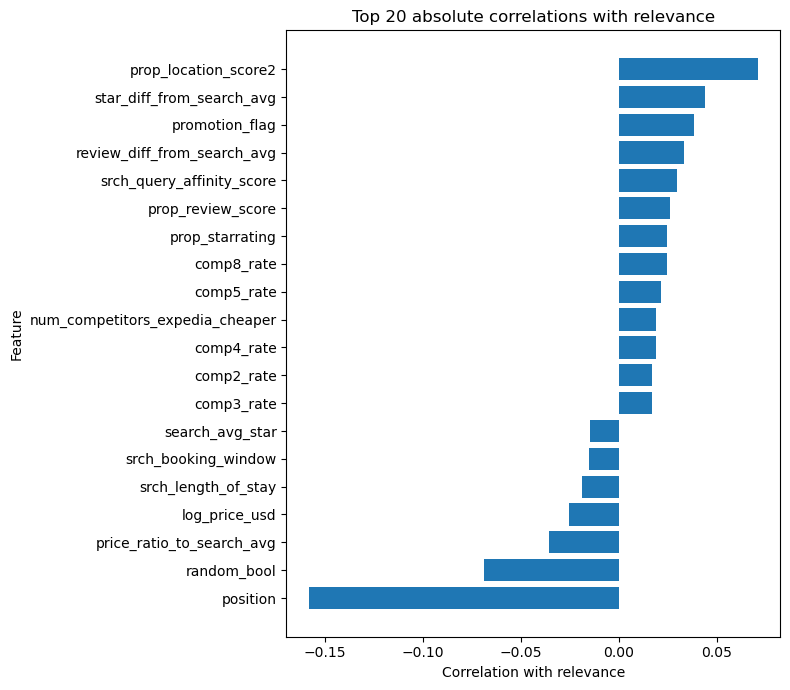

In [ ]:
# plot strongest absolute correlations with relevance

corr_relevance = corr_with_targets["relevance"].dropna()

# Remove target variables themselves from the plot
corr_relevance = corr_relevance.drop(labels=["relevance", "click_bool", "booking_bool"], errors="ignore")

top_corr = corr_relevance.reindex(corr_relevance.abs().sort_values(ascending=False).head(20).index)
top_corr = top_corr.sort_values()

plt.figure(figsize=(8, 7))
plt.barh(top_corr.index, top_corr.values)
plt.xlabel("Correlation with relevance")
plt.ylabel("Feature")
plt.title("Top 20 absolute correlations with relevance")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/top_correlations_with_relevance.png", dpi=300)
plt.show()

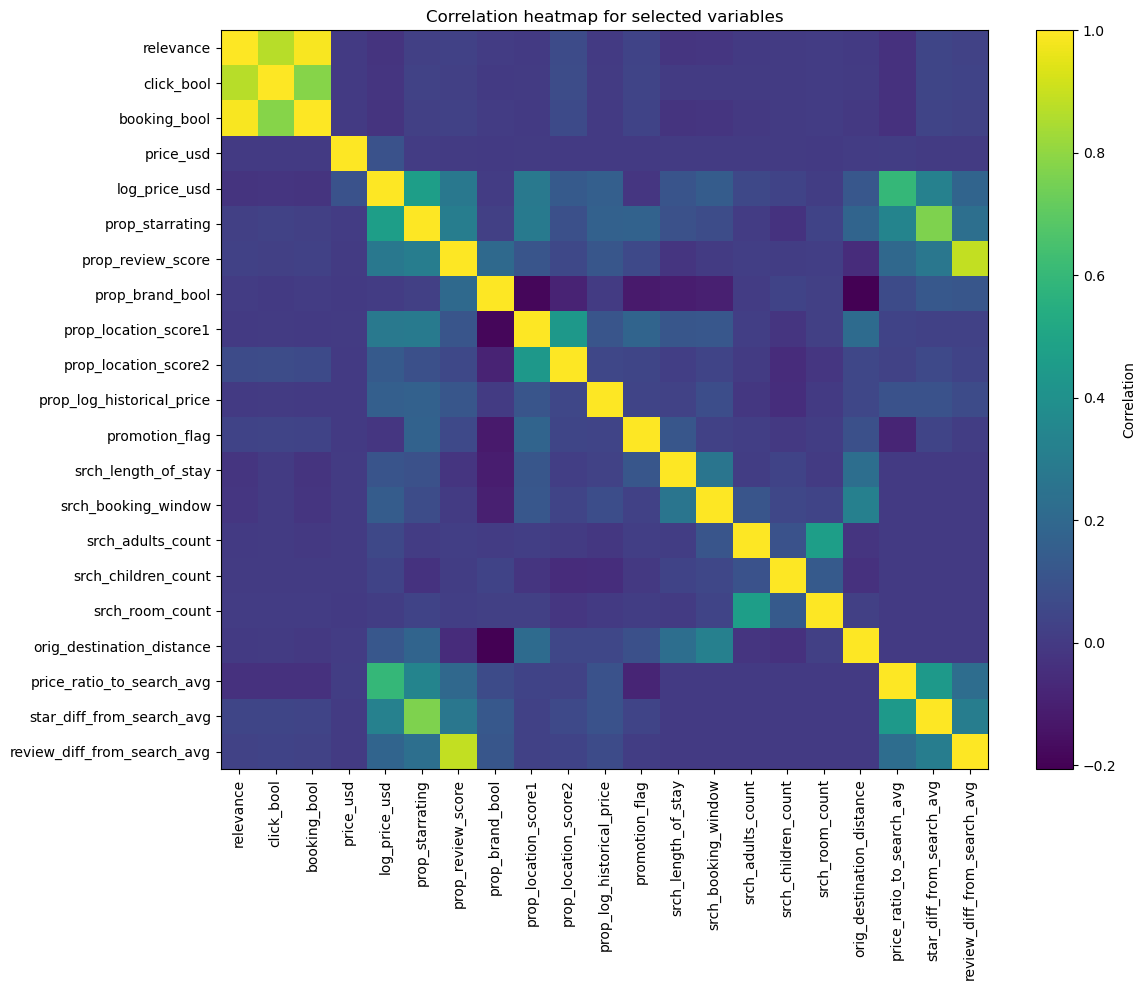

In [ ]:
# correlation heatmap for selected variables

selected_corr_cols = [
    "relevance",
    "click_bool",
    "booking_bool",
    "price_usd",
    "log_price_usd",
    "prop_starrating",
    "prop_review_score",
    "prop_brand_bool",
    "prop_location_score1",
    "prop_location_score2",
    "prop_log_historical_price",
    "promotion_flag",
    "srch_length_of_stay",
    "srch_booking_window",
    "srch_adults_count",
    "srch_children_count",
    "srch_room_count",
    "orig_destination_distance",
    "price_ratio_to_search_avg",
    "star_diff_from_search_avg",
    "review_diff_from_search_avg"
]

selected_corr_cols = [col for col in selected_corr_cols if col in df.columns]

corr_matrix = df[selected_corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation heatmap for selected variables")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/selected_correlation_heatmap.png", dpi=300)
plt.show()

In [ ]:
# simple EDA summary table for report

eda_summary = pd.DataFrame({
    "question": [
        "How many rows?",
        "How many columns?",
        "How many unique searches?",
        "How many unique hotels?",
        "Average hotels per search?",
        "Click rate?",
        "Booking rate?",
        "Percentage searches with click?",
        "Percentage searches with booking?",
        "Median price?",
        "Mean price?",
        "Median hotel star rating?",
        "Median hotel review score?"
    ],
    "answer": [
        len(df),
        df.shape[1],
        df["srch_id"].nunique(),
        df["prop_id"].nunique(),
        hotels_per_search.mean(),
        df["click_bool"].mean() * 100,
        df["booking_bool"].mean() * 100,
        search_level_counts.loc[0, "percentage_with_click"],
        search_level_counts.loc[0, "percentage_with_booking"],
        df["price_usd"].median(),
        df["price_usd"].mean(),
        df["prop_starrating"].median(),
        df["prop_review_score"].median()
    ]
})

eda_summary

,question,answer
0,How many rows?,"4,958,347.0000"
1,How many columns?,75.0000
2,How many unique searches?,"199,795.0000"
3,How many unique hotels?,"129,113.0000"
4,Average hotels per search?,24.8172
5,Click rate?,4.4749
6,Booking rate?,2.7911
7,Percentage searches with click?,100.0000
8,Percentage searches with booking?,69.2660
9,Median price?,122.0000


In [ ]:
# save important EDA tables

overview_df.to_csv(f"{OUTPUT_DIR}/dataset_overview.csv")
hotels_per_search_summary.to_csv(f"{OUTPUT_DIR}/hotels_per_search_summary.csv")
target_counts.to_csv(f"{OUTPUT_DIR}/target_counts.csv")
search_level_counts.to_csv(f"{OUTPUT_DIR}/search_level_counts.csv")
relevance_counts.to_csv(f"{OUTPUT_DIR}/relevance_counts.csv")
star_stats.to_csv(f"{OUTPUT_DIR}/star_rating_stats.csv", index=False)
review_stats.to_csv(f"{OUTPUT_DIR}/review_score_stats.csv", index=False)
promotion_stats.to_csv(f"{OUTPUT_DIR}/promotion_stats.csv", index=False)
brand_stats.to_csv(f"{OUTPUT_DIR}/brand_stats.csv", index=False)
destination_stats.to_csv(f"{OUTPUT_DIR}/destination_stats.csv", index=False)
property_stats.to_csv(f"{OUTPUT_DIR}/property_stats.csv", index=False)
rate_summary.to_csv(f"{OUTPUT_DIR}/competitor_rate_summary.csv", index=False)
inv_summary.to_csv(f"{OUTPUT_DIR}/competitor_inv_summary.csv", index=False)
family_stats.to_csv(f"{OUTPUT_DIR}/family_search_stats.csv", index=False)
domestic_stats.to_csv(f"{OUTPUT_DIR}/domestic_search_stats.csv", index=False)
eda_summary.to_csv(f"{OUTPUT_DIR}/eda_summary_for_report.csv", index=False)

print(f"Saved EDA tables and plots in folder: {OUTPUT_DIR}")

Saved EDA tables and plots in folder: eda_outputs


In [ ]:
# generate short automatic notes for your report

print("EDA NOTES TO INTERPRET MANUALLY")
print("--------------------------------")
print(f"The dataset contains {len(df):,} rows and {df['srch_id'].nunique():,} unique searches.")
print(f"Each search contains on average {hotels_per_search.mean():.2f} hotel options.")
print(f"The click rate is {df['click_bool'].mean() * 100:.3f}% of rows.")
print(f"The booking rate is {df['booking_bool'].mean() * 100:.3f}% of rows.")
print(f"{search_level_counts.loc[0, 'percentage_with_click']:.2f}% of searches contain at least one click.")
print(f"{search_level_counts.loc[0, 'percentage_with_booking']:.2f}% of searches contain at least one booking.")
print()
print("Columns with most missing values:")
print(missing_table.head(10)[["missing_percentage"]])
print()
print("Most important thing to remember:")
print("This is a ranking problem within srch_id, not a normal row-level classification problem.")
print("Position is very useful for understanding clicks/bookings, but should not be used as a final test-time feature.")

EDA NOTES TO INTERPRET MANUALLY
--------------------------------
The dataset contains 4,958,347 rows and 199,795 unique searches.
Each search contains on average 24.82 hotel options.
The click rate is 4.475% of rows.
The booking rate is 2.791% of rows.
100.00% of searches contain at least one click.
69.27% of searches contain at least one booking.

Columns with most missing values:
                         missing_percentage
comp1_rate_percent_diff             98.0954
comp6_rate_percent_diff             98.0604
comp1_rate                          97.5813
comp1_inv                           97.3871
comp4_rate_percent_diff             97.3563
gross_bookings_usd                  97.2089
comp7_rate_percent_diff             97.2064
comp6_rate                          95.1565
visitor_hist_starrating             94.9204
visitor_hist_adr_usd                94.8977

Most important thing to remember:
This is a ranking problem within srch_id, not a normal row-level classification problem.
Positio

Outliers

In [ ]:
outlier_cols = [
    "price_usd",
    "srch_length_of_stay",
    "srch_booking_window",
    "srch_adults_count",
    "srch_children_count",
    "srch_room_count",
    "orig_destination_distance"
]

df[outlier_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99, 0.999]).T

,count,mean,std,min,1%,5%,50%,95%,99%,99.9%,max
price_usd,"4,958,347.0000",254.2096,"16,001.2371",0.0000,34.0000,51.0000,122.0000,356.0000,599.0000,"2,060.0356","19,726,328.0000"
srch_length_of_stay,"4,958,347.0000",2.3854,2.0532,1.0000,1.0000,1.0000,2.0000,6.0000,10.0000,20.0000,57.0000
srch_booking_window,"4,958,347.0000",37.4742,51.9934,0.0000,0.0000,0.0000,17.0000,150.0000,243.0000,337.0000,492.0000
srch_adults_count,"4,958,347.0000",1.9726,0.8571,1.0000,1.0000,1.0000,2.0000,4.0000,5.0000,8.0000,9.0000
srch_children_count,"4,958,347.0000",0.3505,0.7326,0.0000,0.0000,0.0000,0.0000,2.0000,3.0000,5.0000,9.0000
srch_room_count,"4,958,347.0000",1.1105,0.4172,1.0000,1.0000,1.0000,1.0000,2.0000,3.0000,6.0000,8.0000
orig_destination_distance,"3,350,565.0000","1,301.2344","2,023.9514",0.0100,0.9500,13.6100,386.6000,"5,828.7580","9,677.4700","10,689.4944","11,666.6400"


Invalid values check

In [ ]:
# ============================================================
# Incorrect / invalid value checks
# ============================================================

invalid_checks = {}

# Range checks
invalid_checks["prop_starrating_not_0_to_5"] = ~df["prop_starrating"].between(0, 5)
invalid_checks["prop_review_score_not_0_to_5"] = ~df["prop_review_score"].between(0, 5) & df["prop_review_score"].notna()
invalid_checks["price_usd_negative"] = df["price_usd"] < 0
invalid_checks["srch_length_of_stay_not_positive"] = df["srch_length_of_stay"] <= 0
invalid_checks["srch_booking_window_negative"] = df["srch_booking_window"] < 0
invalid_checks["srch_adults_count_not_positive"] = df["srch_adults_count"] <= 0
invalid_checks["srch_children_count_negative"] = df["srch_children_count"] < 0
invalid_checks["srch_room_count_not_positive"] = df["srch_room_count"] <= 0
invalid_checks["orig_destination_distance_negative"] = df["orig_destination_distance"] < 0

# Binary checks
binary_cols = [
    "prop_brand_bool",
    "promotion_flag",
    "random_bool",
    "srch_saturday_night_bool",
    "click_bool",
    "booking_bool"
]

for col in binary_cols:
    if col in df.columns:
        invalid_checks[f"{col}_not_binary"] = ~df[col].isin([0, 1]) & df[col].notna()

# Competitor rate checks: should be -1, 0, 1, or missing
rate_cols = [col for col in df.columns if col.startswith("comp") and col.endswith("_rate")]
for col in rate_cols:
    invalid_checks[f"{col}_invalid"] = ~df[col].isin([-1, 0, 1]) & df[col].notna()

# Competitor inventory checks: should be 0, 1, or missing
inv_cols = [col for col in df.columns if col.startswith("comp") and col.endswith("_inv")]
for col in inv_cols:
    invalid_checks[f"{col}_invalid"] = ~df[col].isin([0, 1]) & df[col].notna()

# Review score should usually be in steps of 0.5
valid_review_steps = np.arange(0, 5.5, 0.5)
invalid_checks["prop_review_score_not_half_step"] = (
    ~df["prop_review_score"].isin(valid_review_steps) & df["prop_review_score"].notna()
)

# Summarise results
invalid_summary = pd.DataFrame({
    "invalid_count": {name: mask.sum() for name, mask in invalid_checks.items()},
    "invalid_percentage": {name: mask.mean() * 100 for name, mask in invalid_checks.items()}
}).sort_values("invalid_count", ascending=False)

invalid_summary

,invalid_count,invalid_percentage
comp8_inv_invalid,31115,0.6275
comp5_inv_invalid,27084,0.5462
comp3_inv_invalid,26818,0.5409
comp2_inv_invalid,18217,0.3674
comp4_inv_invalid,4531,0.0914
comp7_inv_invalid,4283,0.0864
comp6_inv_invalid,2795,0.0564
comp1_inv_invalid,1468,0.0296
prop_starrating_not_0_to_5,0,0.0000
prop_review_score_not_0_to_5,0,0.0000


In [ ]:
# Show only checks where invalid values were found
invalid_summary[invalid_summary["invalid_count"] > 0]

,invalid_count,invalid_percentage
comp8_inv_invalid,31115,0.6275
comp5_inv_invalid,27084,0.5462
comp3_inv_invalid,26818,0.5409
comp2_inv_invalid,18217,0.3674
comp4_inv_invalid,4531,0.0914
comp7_inv_invalid,4283,0.0864
comp6_inv_invalid,2795,0.0564
comp1_inv_invalid,1468,0.0296


In [ ]:
# ============================================================
# Inspect invalid competitor inventory values
# ============================================================

invalid_inv_cols = [
    "comp8_inv",
    "comp5_inv",
    "comp3_inv",
    "comp2_inv",
    "comp4_inv",
    "comp7_inv",
    "comp6_inv",
    "comp1_inv"
]

# According to the assignment description, valid compX_inv values are:
# 1 = competitor has no availability
# 0 = both Expedia and competitor have availability
# NaN = no competitor data
valid_inv_values = [0, 1]

for col in invalid_inv_cols:
    mask = ~df[col].isin(valid_inv_values) & df[col].notna()
    
    print("\n" + "="*80)
    print(f"Column: {col}")
    print(f"Invalid rows: {mask.sum():,}")
    print(f"Invalid percentage: {mask.mean() * 100:.4f}%")
    print("\nInvalid value counts:")
    print(df.loc[mask, col].value_counts(dropna=False))
    
    print("\nExample invalid rows:")
    display(
        df.loc[mask, [
            "srch_id",
            "prop_id",
            col,
            "price_usd",
            "position",
            "click_bool",
            "booking_bool"
        ]].head(5)
    )


Column: comp8_inv
Invalid rows: 31,115
Invalid percentage: 0.6275%

Invalid value counts:
comp8_inv
-1.0000    31115
Name: count, dtype: int64

Example invalid rows:


,srch_id,prop_id,comp8_inv,price_usd,position,click_bool,booking_bool
101,11,69993,-1.0000,34.0000,27,0,0
784,65,7860,-1.0000,199.0000,26,0,0
899,72,53494,-1.0000,349.0000,24,1,1
1107,81,67867,-1.0000,85.0000,16,0,0
1206,87,33406,-1.0000,96.6500,2,1,1



Column: comp5_inv
Invalid rows: 27,084
Invalid percentage: 0.5462%

Invalid value counts:
comp5_inv
-1.0000    27084
Name: count, dtype: int64

Example invalid rows:


,srch_id,prop_id,comp5_inv,price_usd,position,click_bool,booking_bool
12,1,68914,-1.0000,100.8900,13,1,1
15,1,85728,-1.0000,100.8900,31,0,0
18,1,88218,-1.0000,115.1200,8,0,0
23,1,107872,-1.0000,128.0600,12,0,0
26,1,114766,-1.0000,104.7700,33,0,0



Column: comp3_inv
Invalid rows: 26,818
Invalid percentage: 0.5409%

Invalid value counts:
comp3_inv
-1.0000    26818
Name: count, dtype: int64

Example invalid rows:


...

,srch_id,prop_id,comp7_inv,price_usd,position,click_bool,booking_bool
1275,93,32536,-1.0000,165.0000,21,0,0
1352,96,89919,-1.0000,350.0000,7,0,0
3183,213,10282,-1.0000,113.2000,4,0,0
5197,376,90120,-1.0000,211.0000,3,1,1
5377,390,27692,-1.0000,190.6700,18,0,0



Column: comp6_inv
Invalid rows: 2,795
Invalid percentage: 0.0564%

Invalid value counts:
comp6_inv
-1.0000    2795
Name: count, dtype: int64

Example invalid rows:


,srch_id,prop_id,comp6_inv,price_usd,position,click_bool,booking_bool
1275,93,32536,-1.0000,165.0000,21,0,0
3183,213,10282,-1.0000,113.2000,4,0,0
5384,390,56226,-1.0000,144.2100,28,0,0
6187,439,88756,-1.0000,156.7600,2,0,0
6420,460,96887,-1.0000,85.5600,27,0,0



Column: comp1_inv
Invalid rows: 1,468
Invalid percentage: 0.0296%

Invalid value counts:
comp1_inv
-1.0000    1468
Name: count, dtype: int64

Example invalid rows:


,srch_id,prop_id,comp1_inv,price_usd,position,click_bool,booking_bool
6299,447,127853,-1.0000,182.9400,32,0,0
13324,929,87862,-1.0000,111.6100,26,0,0
13843,955,90954,-1.0000,219.4500,33,0,0
17333,1185,20403,-1.0000,105.0000,12,0,0
17355,1185,124069,-1.0000,198.0000,31,0,0
